In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [31]:
df = pd.read_excel(
    "retail_data_pakistan_large_with_category.xlsx",
    sheet_name="New Working Sheet",
)

In [32]:
df.head(10)

,transaction_id,customer_id,product_id,quantity,price,date,Date Difference,Total Quantity,Total Price,Recency,Frequency,Monetry,Active vs Inactive,Location
0,350,1,43,4,388852,2022-09-22,832,10,1220854,2,6,8,Inactive,Lahore
1,641,3,34,1,86615,2024-02-08,328,7,744263,7,4,4,Active,Karachi
2,866,4,35,1,56239,2023-09-15,474,3,352479,5,1,1,Active,Rawalpindi
3,14,5,20,5,740600,2024-05-19,227,12,1399140,8,7,8,Active,Multan
4,757,6,43,2,194426,2024-06-11,204,6,597732,9,3,3,Active,Islamabad
5,160,7,19,4,449632,2023-03-06,667,6,760768,4,3,5,Inactive,Islamabad
6,967,8,11,3,304362,2024-04-12,264,3,304362,8,1,1,Active,Islamabad
7,119,9,34,3,259845,2024-01-03,364,10,795050,6,6,5,Active,Islamabad
8,555,10,44,1,138098,2024-07-07,178,4,381701,9,1,2,Active,Karachi
9,977,11,45,4,342400,2023-01-04,728,14,1230429,3,8,8,Inactive,Karachi


In [207]:
loc = df.Location
loc.unique()

array(['Lahore', 'Karachi', 'Rawalpindi', 'Multan', 'Islamabad',
       'Peshawar', 'Faisalabad'], dtype=object)

In [33]:
df_2 = df.drop(columns=["transaction_id", "customer_id", "product_id",	"quantity", "price", "date", "Date Difference",	"Total Quantity",	"Total Price", "Active vs Inactive"], axis="columns")
df_2

,Recency,Frequency,Monetry,Location
0,2,6,8,Lahore
1,7,4,4,Karachi
2,5,1,1,Rawalpindi
3,8,7,8,Multan
4,9,3,3,Islamabad
...,...,...,...,...
436,4,6,5,Islamabad
437,10,4,5,Peshawar
438,6,4,2,Peshawar
439,8,2,2,Rawalpindi


In [34]:
df_2.isna().sum()

Recency      0
Frequency    0
Monetry      0
Location     0
dtype: int64

In [39]:
encode = LabelEncoder()
df_2.Location = encode.fit_transform(df_2["Location"])


In [40]:
df_2.head(10)

,Recency,Frequency,Monetry,Location
0,2,6,8,3
1,7,4,4,2
2,5,1,1,6
3,8,7,8,4
4,9,3,3,1
5,4,3,5,1
6,8,1,1,1
7,6,6,5,1
8,9,1,2,2
9,3,8,8,2


In [44]:
mean = KMeans(n_clusters=2)
mean.fit(df_2[["Recency",	"Frequency",	"Monetry",	"Location"]])

KMeans(n_clusters=2)

In [45]:
mean.predict(df_2[["Recency",	"Frequency",	"Monetry",	"Location"]])

array([0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,

In [158]:
scale = MinMaxScaler()
df_2[["Recency",	"Frequency",	"Monetry",	"Location"]] = scale.fit_transform(df_2[["Recency",	"Frequency",	"Monetry",	"Location"]])

In [176]:
mean = KMeans(n_clusters=2)
mean.fit(df_2[["Recency",	"Frequency",	"Monetry",	"Location"]])

KMeans(n_clusters=2)

In [177]:
mymean = mean.predict(df_2[["Recency",	"Frequency",	"Monetry",	"Location"]])

In [178]:
mymean

array([0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,

In [179]:
r = range(1, 9)
sse = []

for i in r:
    k = KMeans(n_clusters=i)
    k.fit(df_2[["Recency",	"Frequency",	"Monetry",	"Location"]])
    sse.append(k.inertia_)

In [180]:
sse

[182.13361887965056,
 113.80849175133837,
 95.12681916793588,
 77.93241171552873,
 66.3938385744479,
 59.20799117434741,
 53.08204126582774,
 47.33460411073307]

Text(0, 0.5, 'Sum of Squared Error')

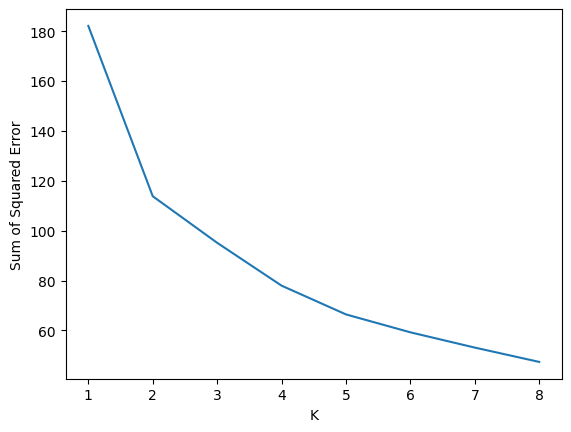

In [181]:
plt.plot(r, sse)
plt.xlabel("K")
plt.ylabel("Sum of Squared Error")

In [182]:
df_2["cluster"] = mymean

In [186]:
df_2.head(10)

,Recency,Frequency,Monetry,Location,cluster
0,0.111111,0.666667,0.888889,0.500000,0
1,0.666667,0.444444,0.444444,0.333333,0
2,0.444444,0.111111,0.111111,1.000000,1
3,0.777778,0.777778,0.888889,0.666667,0
4,0.888889,0.333333,0.333333,0.166667,1
5,0.333333,0.333333,0.555556,0.166667,1
6,0.777778,0.111111,0.111111,0.166667,1
7,0.555556,0.666667,0.555556,0.166667,0
8,0.888889,0.111111,0.222222,0.333333,1
9,0.222222,0.888889,0.888889,0.333333,0


In [187]:
df_2[["Recency",	"Frequency",	"Monetry",	"Location"]] = scale.inverse_transform(df_2[["Recency",	"Frequency",	"Monetry",	"Location"]])
# scale.inverse_transform(df_2[["Recency",	"Frequency",	"Monetry",	"Location"]])

In [188]:
df_2.head(10)

,Recency,Frequency,Monetry,Location,cluster
0,2.0,6.0,8.0,3.0,0
1,7.0,4.0,4.0,2.0,0
2,5.0,1.0,1.0,6.0,1
3,8.0,7.0,8.0,4.0,0
4,9.0,3.0,3.0,1.0,1
5,4.0,3.0,5.0,1.0,1
6,8.0,1.0,1.0,1.0,1
7,6.0,6.0,5.0,1.0,0
8,9.0,1.0,2.0,2.0,1
9,3.0,8.0,8.0,2.0,0


In [189]:
df_2["Buy"] = df_2["cluster"].apply(lambda x: "Yes" if x == 0 else "No")

In [190]:
df_3 = df_2.drop(columns="cluster")

In [191]:
df_3.head(10)

,Recency,Frequency,Monetry,Location,Buy
0,2.0,6.0,8.0,3.0,Yes
1,7.0,4.0,4.0,2.0,Yes
2,5.0,1.0,1.0,6.0,No
3,8.0,7.0,8.0,4.0,Yes
4,9.0,3.0,3.0,1.0,No
5,4.0,3.0,5.0,1.0,No
6,8.0,1.0,1.0,1.0,No
7,6.0,6.0,5.0,1.0,Yes
8,9.0,1.0,2.0,2.0,No
9,3.0,8.0,8.0,2.0,Yes


In [192]:
model_params = {
    "svm": {
        "model": SVC(gamma="auto"),
        "param": {
            'C': [1, 10, 20],
            'kernel': ['rbf', 'linear']
        }
    },
    "random_forest": {
        'model': RandomForestClassifier(),
        'param': {
            'n_estimators': [1, 5, 10]
        }
    },
    "logistic_regression": {
        'model': LogisticRegression(solver='liblinear', multi_class='auto'),
        'param': {
            'C': [1, 5, 10]
        }
    },
    "decision_tree": {
        'model': DecisionTreeClassifier(),
        'param': {
            "criterion": ["gini", "entropy", "log_loss"]
        }
    }
}

In [193]:
scores = []
for key, value in model_params.items():
    grid = GridSearchCV(value['model'], value['param'], cv=5, return_train_score=False)
    grid.fit(df_3[["Recency",	"Frequency",	"Monetry",	"Location"]], df_3.Buy)
    scores.append({
        'model': key,
        'best_score': grid.best_score_,
        'best_params': grid.best_params_
    })

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib

In [194]:
scores

[{'model': 'svm',
  'best_score': np.float64(1.0),
  'best_params': {'C': 10, 'kernel': 'linear'}},
 {'model': 'random_forest',
  'best_score': np.float64(0.9772982635342187),
  'best_params': {'n_estimators': 10}},
 {'model': 'logistic_regression',
  'best_score': np.float64(0.9818437180796732),
  'best_params': {'C': 5}},
 {'model': 'decision_tree',
  'best_score': np.float64(0.9704800817160368),
  'best_params': {'criterion': 'log_loss'}}]

In [195]:
data = []
a = []
for i in scores:
    for keys, values in i.items():
        a.append(values)
    
    data.append(a)
    a = []

print(data)

[['svm', np.float64(1.0), {'C': 10, 'kernel': 'linear'}], ['random_forest', np.float64(0.9772982635342187), {'n_estimators': 10}], ['logistic_regression', np.float64(0.9818437180796732), {'C': 5}], ['decision_tree', np.float64(0.9704800817160368), {'criterion': 'log_loss'}]]


In [196]:
df_4 = pd.DataFrame(data, columns=["Model", "Best_Score", "Best_Param"])
df_4

,Model,Best_Score,Best_Param
0,svm,1.000000,"{'C': 10, 'kernel': 'linear'}"
1,random_forest,0.977298,{'n_estimators': 10}
2,logistic_regression,0.981844,{'C': 5}
3,decision_tree,0.970480,{'criterion': 'log_loss'}


In [197]:
X = df_3.drop(columns="Buy")
y = df_3.Buy

In [198]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [199]:
svm = SVC(C=10, kernel="linear", gamma="auto", probability=True, )
svm.fit(X_train, y_train)


SVC(C=10, gamma='auto', kernel='linear', probability=True)

In [200]:
svm.score(X_test, y_test)

1.0

In [201]:
svm.predict(X_test)

array(['No', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes',
       'Yes', 'No', 'No', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'Yes',
       'Yes', 'No', 'No', 'No', 'Yes', 'No', 'No', 'Yes', 'No', 'No',
       'No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes',
       'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'No',
       'Yes', 'No', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes',
       'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'No', 'No', 'Yes', 'No',
       'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes',
       'No', 'Yes', 'No', 'No', 'No', 'No', 'Yes', 'Yes', 'Yes'],
      dtype=object)

In [202]:
import joblib
joblib.dump(svm, "Customer_Churn_prediction.pkl")

['Customer_Churn_prediction.pkl']

In [203]:
pre = joblib.load("Customer_Churn_prediction.pkl")

In [209]:
df_4 = df_3.copy()

In [213]:
df_4["Location_2"] = loc
city = {}
for i, j in zip(df_4.Location, df_4.Location_2):
    city[j] = i

In [214]:
city

{'Lahore': 3.0,
 'Karachi': 2.0,
 'Rawalpindi': 6.0,
 'Multan': 4.0,
 'Islamabad': 1.0,
 'Peshawar': 5.0,
 'Faisalabad': 0.0}